In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

colours = sns.color_palette("muted")
sns.set_theme(style='whitegrid')

/Users/aedanbullen/Desktop/Candidatures/Trading Simulation/Trading-Simulation/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [3]:
#=== configuration =======
symbol = "AAPL"
start = "2015-01-01"
end = '2025-01-01'
starting_cash = 10000
n_sims = 1000 # number of Monte Carlo sims per strategy
conf_lo = 5 # lo percentile for confidence band
conf_hi = 95 # high ---------"----------------
seed = 42

In [4]:
#======== download and clean ======

raw = yf.download(symbol, start=start, end=end, auto_adjust=True)
price = raw["Close"].squeeze().dropna() # remember squeeze() gets rid of titles in series.
daily_returns = price.pct_change().fillna(0)

n_days = len(price)
print(f"{symbol}: {n_days} trading days loaded {start} to {end}")

[*********************100%***********************]  1 of 1 completed

AAPL: 2516 trading days loaded 2015-01-01 to 2025-01-01


In [5]:
# === strategies (copied from trading_stratefy_tests.ipynb) ===
buy_and_hold = pd.Series(1, index=price.index) # makes a series filled with 1s, with name dates.
#1 means to hold/buy every single day, always in the market. Most basic strategy, so used to compare other strategies.
#Effectively just never selling the stock. Watching what happens to the price.

momentum = (price.diff() > 0).astype(int) # if price goes up, then buy. If price.diff() between days is
#>0, then buy. astype(int) converts True/False to 1/0.

short_ma = price.rolling(20).mean() # buy when short-term avg > long term avg.
long_ma = price.rolling(50).mean() # rolling function makes a rolling window looking at last n days, taking average.
ma_cross = (short_ma > long_ma).astype(int) # this is the MAC method.

delta = price.diff()
gain = delta.clip(lower=0).rolling(14).mean() # if negative change, clip to 0. if positive keep.
loss = -delta.clip(upper=0).rolling(14).mean() # if positive clip to 0, if negative keep.
rsi = 100 - (100 / (1 + gain / loss)) # formula relative strength index RSI = 100 - 100 / (1 + RS)
# if RSI is near 100, mostly all gains recently, so overbought stock.
# if near 0, almost all losses recently, so oversold.
rsi_signal = (rsi < 30).astype(int) # buy when oversold.
#Remember buy low, sell high. Bets that the market overreacts when oversold, that price will snap back to true value afterwards. thus profit.
#Idea called mean reversion, idea that prices tend to drift back to long term avg.

ma = price.rolling(20).mean()
std = price.rolling(20).std()
lower_band = ma - 2 * std #lower band sits at 2std below mean (price below this is unusual/significant)
bb_signal = (price < lower_band).astype(int) # buy if drops below lower band, as it's cheap.



strategies = {
    "HOLD": buy_and_hold,
    "MOM": momentum,
    "Moving Average Crossover": ma_cross,
    "RSI": rsi_signal,
    "Bollinger Bands": bb_signal

}

In [ ]:
# ====== Helper functions =====

def equity_curve(signal: pd.Series, returns: pd.Series) -> pd.Series:
    shifted_signal = signal.shift(1).fillna(0) # 1 day later. Cannot use today's signal to trade today.
    # the signal is the 1/0 trade/don't boolean. Also fills any nans.

    daily_growth = 1 + shifted_signal * returns # shifted signal (using whatever strategy) times returns
    # what growth u get if you use said method.
    # if signal 0 (out of market) 1 + 0 * return = 1.0, no change
    # if signal 1 (in market) 1 + 1 * return = ...
    # NB 1+ because of percentage change.

    return daily_growth.cumprod() * starting_cash # compound over time. Multiplies daily growth factors and original stock.

def risk_metrics(curve: pd.Series) -> dict:
    """ compute CAGR, sharpe, max drawdown, and 5th ptl final value"""

    returns = curve.pct_change().dropna() # daily percentage changes. have dropna due to no 0th day to cf 1st day.
    trading_years = len(curve) / 252

    # compound annual growth rate.
    cagr = (curve.iloc[-1] / starting_cash) ** (1 / trading_years) - 1  # final = starting x rate ^ years. rearrange for rate.

    # find Sharpe
    sharpe = (returns.mean() / returns.std()) * np.sqrt(252) if returns.std() > 0 else 0 # div by 0 guard. also set risk-free rate to 0
    # sharpe asks how much return getting per unit risk. Average daily return/volatility (std), scaled to annual by root 252. 
    # think of as a parameter to assess how much worth a risk had. 1.5 is considered strong. less than 1 is bad.

    # max drawdown.
    rolling_max = curve.cummax() # tracks portfolios all-time high over time. 
    drawdown = (curve - rolling_max) / rolling_max # how far below the peak you are (zero or negative.) as a percentage
    max_drawdown = drawdown.min() # worst, most negative point.
    #MD asks what the worst peak to trough loss experienced is. Measures most painful moment in portfolio.

    return {"cagr": cagr, "sharpe": sharpe, "max_drawdown": max_drawdown, "final": curve.iloc[-1]}

In [11]:
# ====== Monte Carlo =======

# so -called bootstrapping method. scrambling historical returns to simulate alternative histories.
rng = np.random.default_rng(seed) # rnd numner gen
ret_array = daily_returns.values # converts pd series into Numpy array just because it's easier

mc_results = {name: [] for name in strategies} # this gives a structure like {"HOLD": [], "Momentum": [], "MA Crossover": [], ...}
mc_curves = {name: [] for name in strategies}

for sim in range(n_sims):

    idx_boot = rng.integers(0, n_days, size=n_days) #draws n_days random integers between 0 and n_days. so the indices are sampled w/ replacement.
    boot_rets = pd.Series(ret_array[idx_boot], index=daily_returns.index) #pandas series of scrambled returns data.

    for name, signal in strategies.items(): 
        curve = equity_curve(signal, boot_rets) # runs strategies against scrambled histories.
        mc_results[name].append(curve.iloc[-1])# saves final portfolio value to dictionary
        mc_curves[name].append(curve.values) # saves full path for plotting later

print(f"Done: {n_sims} simulations {len(strategies)} strategies")

Done: 1000 simulations 5 strategies


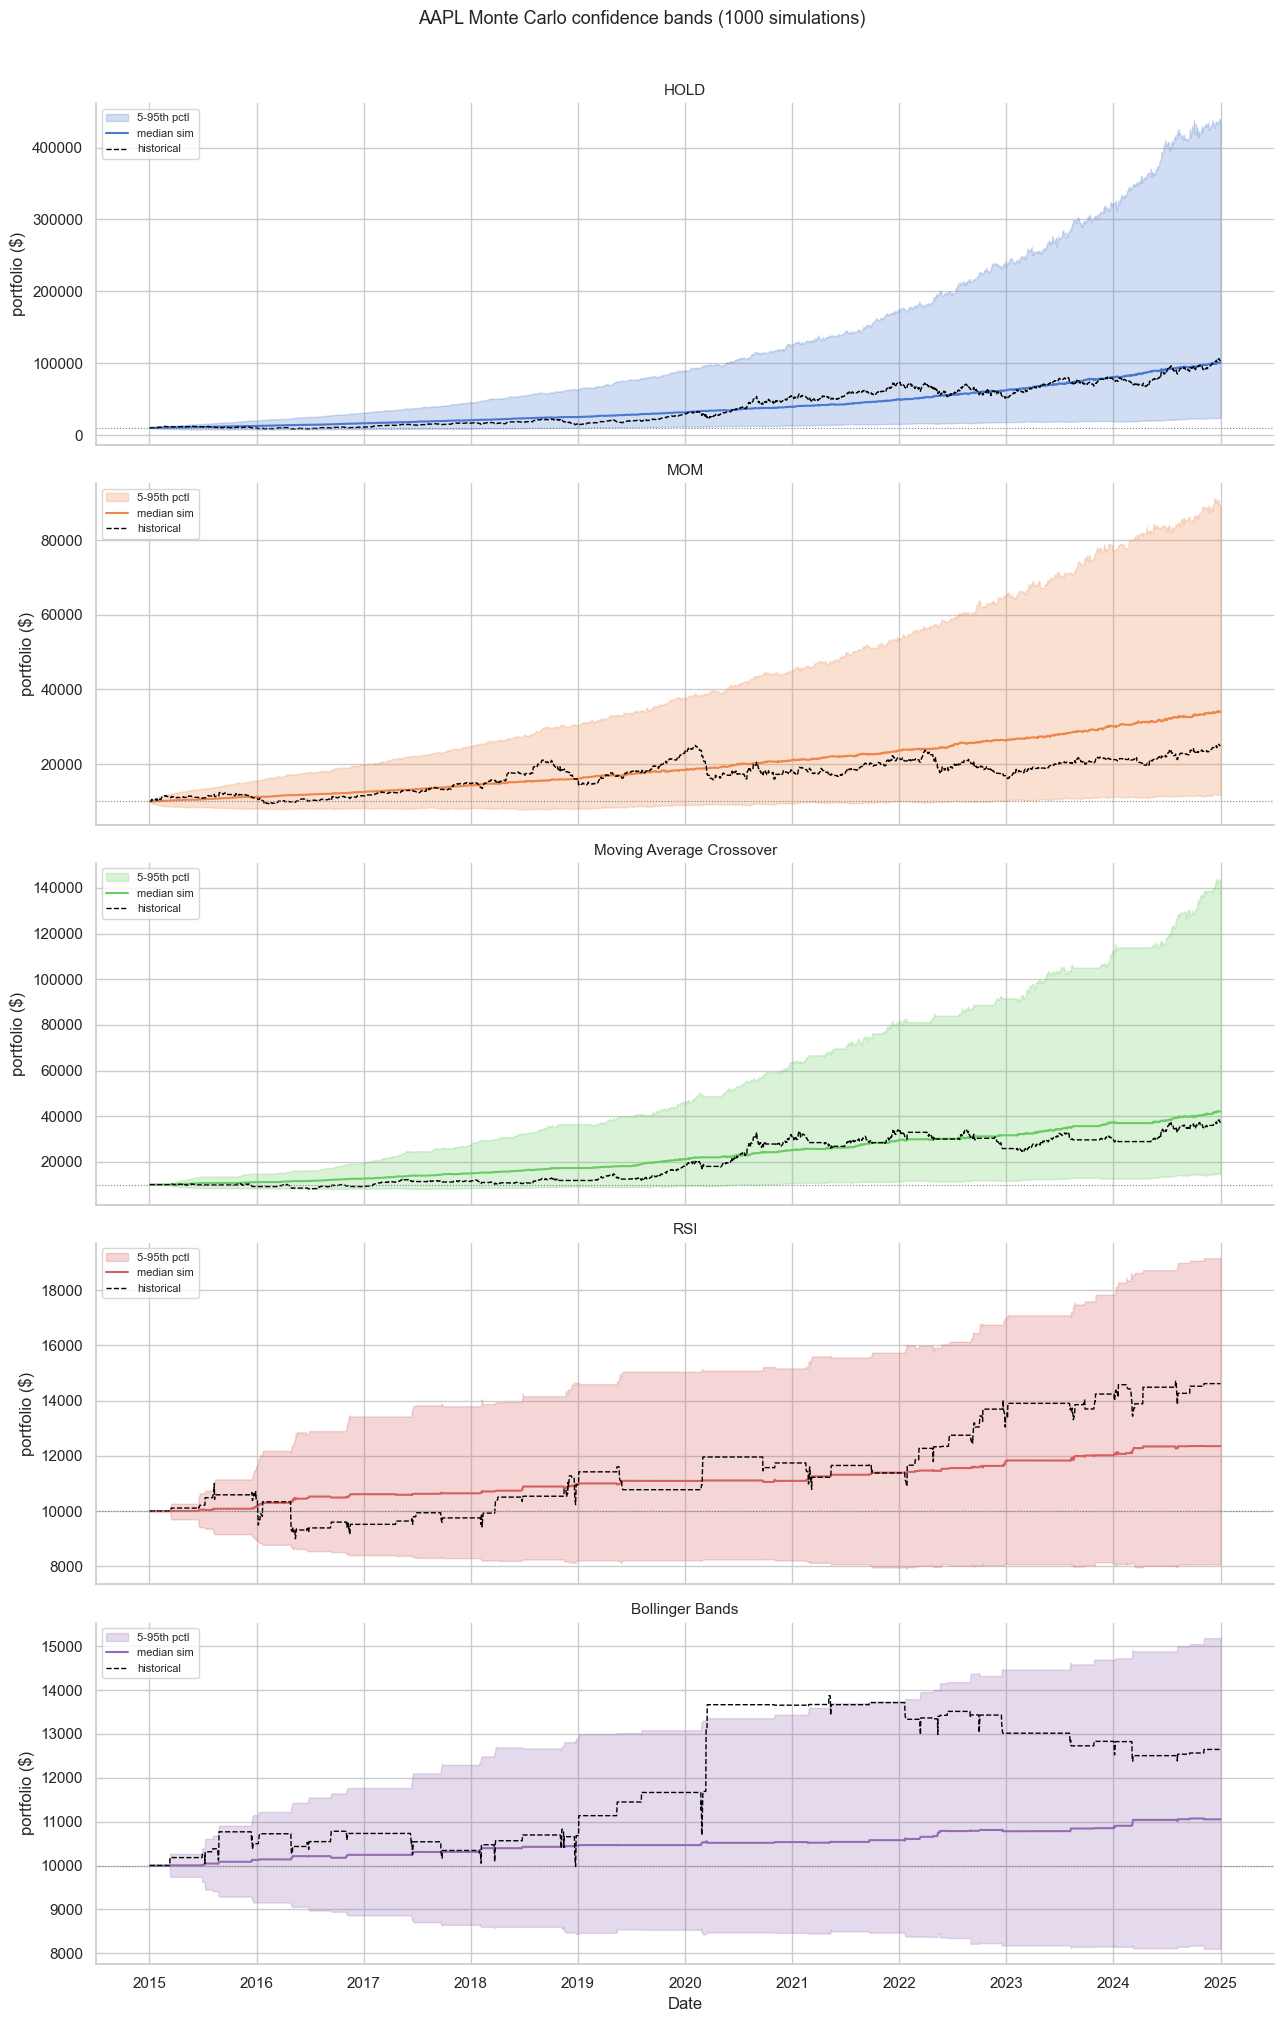

In [ ]:
# ==== plot confidence bands ==
fig, axes = plt.subplots(len(strategies), 1, figsize = (13, 4 * len(strategies)), sharex=True) # gives figure 1 column strategies rows.

dates = price.index

for ax, (name, signal), col in zip(axes, strategies.items(), colours): #.items() gets each row of dictionary.
    # iterates over all three things in lockstep. each ax is the subplot to draw on.
    curves_arr = np.array(mc_curves[name]) # set of all mc curves for given strategy.
    lo = np.percentile(curves_arr, conf_lo, axis=0)
    hi = np.percentile(curves_arr, conf_hi, axis = 0)
    med = np.percentile(curves_arr, 50, axis=0)

    historical_curve = equity_curve(signal, daily_returns) # curve using method for actual data.

    ax.fill_between(dates, lo, hi, alpha=.25, color=col, label=f"{conf_lo}-{conf_hi}th pctl")
    ax.plot(dates, med, color=col, linewidth=1.5, label='median sim') # average
    ax.plot(dates, historical_curve, color='black', linewidth=1, linestyle='--', label='historical')
    ax.axhline(starting_cash, color='grey', linewidth=1, linestyle='-')
    ax.set_title(name, fontsize=11)
    ax.set_ylabel('portfolio ($)')
    ax.legend(fontsize=8, loc='upper left')
    sns.despine(ax=ax)

axes[-1].set_xlabel('Date')
fig.suptitle(f'{symbol} Monte Carlo confidence bands ({n_sims} simulations)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

/var/folders/f_/x4ylrm9n6s358t40tf6j9h0w0000gn/T/ipykernel_98853/3966438408.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_melt, x='Strategy', y="final value ($)",


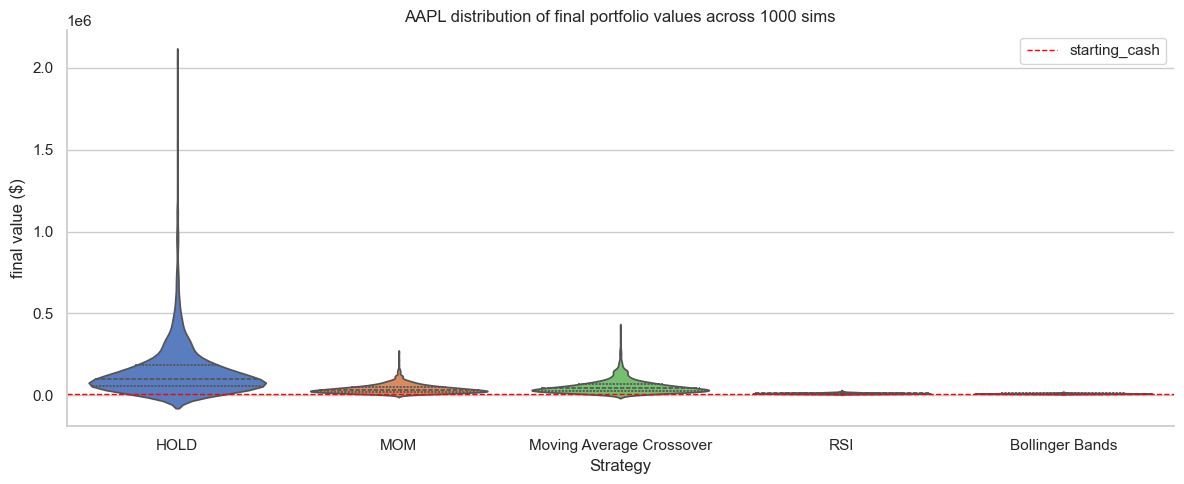

In [15]:
#======= final distributions ========

df_final = pd.DataFrame(mc_results) # looks like {name : [a, b, c , ....] 1000 final values}
df_melt = df_final.melt(var_name='Strategy', value_name="final value ($)")
#melt  makes two columned table with repeating names.

fig, ax = plt.subplots(figsize=(12,5))
sns.violinplot(data=df_melt, x='Strategy', y="final value ($)",
               palette='muted', inner='quartile', ax=ax) # distribution of values for each strategy. shape of 1000 outcomes.

ax.axhline(starting_cash, color='red', linestyle='--', linewidth=1, label='starting_cash')
ax.set_title(f'{symbol} distribution of final portfolio values across {n_sims} sims')
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

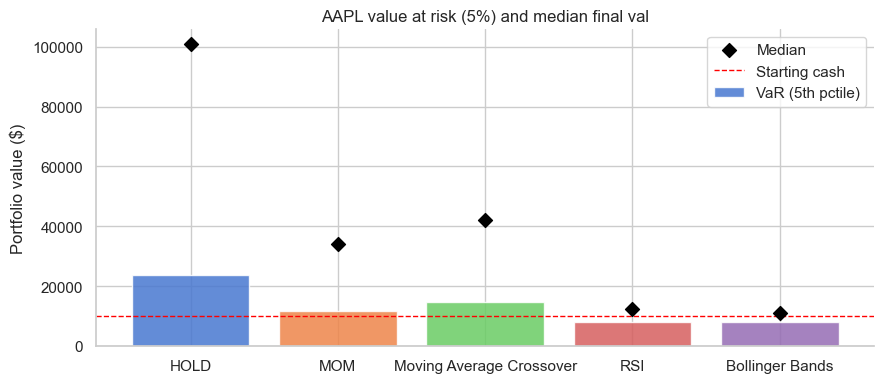


VaR (5th pctl of final portfolio val):
  HOLD                  : $  23,736  (median $ 100,793)
  MOM                   : $  11,761  (median $  33,972)
  Moving Average Crossover: $  14,761  (median $  42,061)
  RSI                   : $   8,072  (median $  12,350)
  Bollinger Bands       : $   8,104  (median $  11,053)


In [19]:
# ===== VaR =======

#VaR what is the worst outcome I should expect? at 5% level usually.

var_5 = {name: np.percentile(vals, 5) for name, vals in mc_results.items()} # 95% of histroies did better than this
med = {name: np.percentile(vals, 50) for name, vals in mc_results.items()} # 50% did better

fig, ax = plt.subplots(figsize = (9,4))
names = list(var_5.keys()) # returns labels (keys)
x = np.arange(len(names))

bars = ax.bar(x, [var_5[n] for n in names], color=colours[:len(names)], alpha=0.85, label="VaR (5th pctile)")
ax.scatter(x, [med[n] for n in names], color="black", zorder=5, label="Median", marker="D", s=50)
ax.axhline(starting_cash, color="red", linestyle="--", linewidth=1, label="Starting cash")

ax.set_xticks(x)
ax.set_xticklabels(names)
ax.set_ylabel("Portfolio value ($)")
ax.set_title(f"{symbol} value at risk (5%) and median final val")
ax.legend()
sns.despine(ax=ax)
plt.tight_layout()
plt.show()

print("\nVaR (5th pctl of final portfolio val):")
for name in names:
    print(f"  {name:<22}: ${var_5[name]:>8,.0f}  (median ${med[name]:>8,.0f})")

In [20]:
# ==== summary table ===

rows = []

for name, signal in strategies.items():
    hist   = risk_metrics(equity_curve(signal, daily_returns))
    finals = mc_results[name]
    rows.append({
        "Strategy":          name,
        "Hist CAGR (%)": f"{hist['cagr']*100:.1f}",
        "Hist Sharpe":    f"{hist['sharpe']:.2f}",
        "Hist MaxDD (%)": f"{hist['max_drawdown']*100:.1f}",
        "MC Median ($)":  f"{np.median(finals):,.0f}",
        "MC 5th pct ($)": f"{np.percentile(finals, 5):,.0f}",
        "MC 95th pct($)": f"{np.percentile(finals, 95):,.0f}",
        "P(loss) %":      f"{100*np.mean(np.array(finals) < starting_cash):.1f}",
    })

summary = pd.DataFrame(rows).set_index("Strategy")
print("\n=== Summary ==")
print(summary.to_string())


=== Summary ==
                         Hist CAGR (%) Hist Sharpe Hist MaxDD (%) MC Median ($) MC 5th pct ($) MC 95th pct($) P(loss) %
Strategy                                                                                                               
HOLD                              26.3        0.96          -38.5       100,793         23,736        436,881       0.2
MOM                                9.6        0.57          -37.0        33,972         11,761         89,290       2.6
Moving Average Crossover          14.0        0.76          -29.1        42,061         14,761        143,537       1.5
RSI                                3.9        0.42          -18.2        12,350          8,072         19,151      20.9
Bollinger Bands                    2.4        0.32          -10.8        11,053          8,104         15,184      28.7
